# Análisis de Producción de Frutales (CSV: Produccion_frutales.csv)

Este notebook es una **guía paso a paso (semana a semana)** para un analista de datos.
Está pensado para que cada ejecución sea reproducible y que puedas explicar fácilmente qué se hizo y por qué.

## ¿Qué encontrarás en este notebook?
- ✅ **Cada semana tiene un objetivo claro** (qué analizamos y por qué).
- 🔍 **Explicaciones en cada paso** para que sea fácil de presentar.
- 📌 **Conclusiones y recomendaciones** listos para reportar.

---

## 📚 Contenido (Tabla de contenidos)
1. [Semana 1: Cargar y entender los datos (EDA inicial)](#Semana-1---Cargar-y-entender-los-datos-(EDA-inicial))
2. [Semana 2: Limpieza y preparación básica](#Semana-2---Limpieza-y-preparación-básica)
3. [Semana 3: Estadísticas descriptivas y distribución](#Semana-3---Estadísticas-descriptivas-y-distribución)
4. [Semana 4: Visualización](#Semana-4---Visualización)
5. [Semana 5: Análisis por grupo (GroupBy)](#Semana-5---Análisis-por-grupo-(GroupBy))
6. [Semana 6: Resumen ejecutivo + recomendaciones](#Semana-6---Resumen-ejecutivo-+-recomendaciones)

---


##  1 - Cargar y entender los datos (EDA inicial)

### Objetivo
- Verificar que los datos se puedan cargar correctamente.
- Comprender la estructura del dataset y detectar problemas evidentes (tipos, valores faltantes, formatos).

### Pasos 
1. Cargar el CSV con las opciones correctas (`sep=';'`, `decimal=','`).
2. Inspeccionar la forma (`shape`), las columnas y los tipos de datos.
3. Revisar valores faltantes y valores únicos en columnas clave.

### ¿Qué debes buscar aquí?
- **Errores de lectura** (e.g., columnas fusionadas por separador incorrecto).
- Formato de números (coma decimal vs punto), fechas, y valores que no sean del tipo esperado.
- Si la variable `Produccion_toneladas` es numérica y si hay filas con valores faltantes.






###  ¿qué encontramos en esta primera parte?
- El archivo se carga correctamente usando `sep=';'` y `decimal=','`.
- La columna `Produccion_toneladas` se lee como numérica; **si no lo fuera**, deberíamos convertirla.
- Es importante validar si hay años/muncipios duplicados y si la variable `Ciclo` es siempre `Anual`.

---

## 2 - Limpieza y preparación básica

### Objetivo
- Asegurar que los datos estén en un formato limpio y consistente para análisis posteriores.
- Detectar duplicados y estandarizar texto.

### Pasos 
1. Crear una copia del DataFrame original para preservar los datos crudos.
2. Normalizar valores de texto (trim y limpieza de espacios).
3. Detectar duplicados exactos y duplicados en las claves principales (`Año`, `Municipio`, `Cultivo`).

### Qué buscar / preguntas clave
- ¿Hay registros repetidos que puedan inflar los totales?
- ¿Hay municipios con espacios al final o diferencias de mayúsculas/minúsculas?
- ¿Los valores numéricos están en el formato correcto?

###     que se debe tener en cuenta 
- Prueba a agrupar los duplicados y comparar la suma vs. el valor original.
- Crea una versión en la que conviertas `Municipio` a mayúsculas (o minúsculas) para ver si cambia el número de valores únicos.

> Nota: En esta etapa no eliminamos datos; solo identificamos los problemas y dejamos comentarios para decidir qué conservar o corregir.


In [5]:
# Semana 2: Limpieza básica y transformaciones

# Copia para no perder el original (buena práctica)
# NOTA: df_clean es el nombre estándar usado en análisis posteriores
df_clean = df.copy()

# Limpiar blancos en columnas de texto
for col in ['Municipio', 'Subregion', 'Cultivo', 'Ciclo']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

# Verificar si existen duplicados exactos
print('Duplicados exactos:', df_clean.duplicated().sum())

# Ejemplo: revisar duplicados por (Año, Municipio, Cultivo)
duplicados_key = df_clean[df_clean.duplicated(subset=['Año', 'Municipio', 'Cultivo'], keep=False)]
print('Registros duplicados por Año/Municipio/Cultivo:', len(duplicados_key))

duplicados_key.head(8)

Duplicados exactos: 39
Registros duplicados por Año/Municipio/Cultivo: 382


,Año,Id_municipio,Municipio,Subregion,Id_cultivo,Cultivo,Ciclo,Produccion_toneladas
7829,2012,76111,Buga,Centro,2041100,Brevo,Anual,2.0
7838,2012,76111,Buga,Centro,2041100,Brevo,Anual,2.0
7849,2011,76111,Buga,Centro,2041100,Brevo,Anual,2.0
7859,2011,76111,Buga,Centro,2041100,Brevo,Anual,2.0
7865,2010,76111,Buga,Centro,2041100,Brevo,Anual,2.0
7880,2010,76111,Buga,Centro,2041100,Brevo,Anual,2.0
7923,2007,76111,Buga,Centro,2041100,Brevo,Anual,2.0
7932,2007,76111,Buga,Centro,2041100,Brevo,Anual,2.0


Esto puede indicar registros repetidos u otros registros correspondientes a diferentes ciclos o cultivos en el mismo municipio/año

Filtrado y selección de datos
---

In [6]:
# 2.1) Filtrado y selección de datos

# Ejemplo 1: filtrar sólo el año 2022
df_2022 = df_clean[df_clean['Año'] == 2022]
print('Registros 2022:', len(df_2022))

# Ejemplo 2: filtrar por subregión (p.ej., Norte)
df_norte = df_clean[df_clean['Subregion'] == 'Norte']
print('Registros subregión Norte:', len(df_norte))

# Ejemplo 3: filtrar por rango de producción (e.g., entre 1.000 y 10.000 toneladas)
df_rango = df_clean[(df_clean['Produccion_toneladas'] >= 1000) & (df_clean['Produccion_toneladas'] <= 10000)]
print('Registros con producción entre 1.000 y 10.000 toneladas:', len(df_rango))

# Ejemplo 4: seleccionar columnas específicas para análisis (reducción de memoria)
df_seleccion = df_clean[['Año', 'Municipio', 'Subregion', 'Produccion_toneladas']]
print('Columnas seleccionadas para análisis:', df_seleccion.columns.tolist())

Registros 2022: 536
Registros subregión Norte: 3677
Registros con producción entre 1.000 y 10.000 toneladas: 2126
Columnas seleccionadas para análisis: ['Año', 'Municipio', 'Subregion', 'Produccion_toneladas']


#### Observaciones de limpieza
- Si encontramos registros duplicados, es clave entender si representan **mismas mediciones** repetidas (errores) o si hay alguna diferencia pequeña (p.ej., producción ligeramente distinta).
- En análisis semanales, debemos decidir si:
  - **Mantener** los duplicados (asumiendo que son reales), o
  - **Aglomerar** (sumar/median) para tener una sola fila por combinación clave.

> En este proyecto, nos enfocaremos en un análisis exploratorio y dejaremos los duplicados para más adelante, a menos que afecten claramente un resultado.

##  3 - Estadísticas descriptivas y distribución

### Objetivo
- Entender cómo se distribuye la producción y qué tan representativos son la media y la mediana.
- Detectar valores extremos (outliers) y cuantificar su impacto.

### Pasos 
1. Calcular estadísticas globales (media, mediana, desviación, percentiles).
2. Calcular IQR y rangos de outliers para tener un criterio objetivo.
3. Mostrar los valores más altos y más bajos para entender qué datos están en la cola.

### ¿Qué analizamos aquí?
- ¿La distribución es simétrica, sesgada a la derecha o a la izquierda?
- ¿Cuál es el valor típico (mediana) frente al promedio?
- ¿Cuántos registros están fuera del rango esperado (IQR)?

### Tener en cuenta
- Si la media > mediana, probablemente hay valores extremos que “tiran” la media hacia arriba.
- Los outliers no deben eliminarse sin análisis; pueden indicar municipios grandes o errores de captura.


In [7]:
# Semana 3: Estadísticas descriptivas

describe = df_clean['Produccion_toneladas'].describe()
print(describe)

# Calcular percentiles adicionales
percentiles = df_clean['Produccion_toneladas'].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.99])
print('\nPercentiles clave:')
print(percentiles)

# Calcular IQR y outliers básicos (IQR method)
q1 = percentiles.loc[0.25]
q3 = percentiles.loc[0.75]
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print(f'\nIQR: {iqr:.2f}, rango outliers: [{lower:.2f}, {upper:.2f}]')

# Mostrar algunos valores extremos
print('\nTop 5 producciones más altas:')
print(df_clean.nlargest(5, 'Produccion_toneladas')[['Año','Municipio','Produccion_toneladas']])

print('\nTop 5 producciones más bajas (distintas de 0):')
print(df_clean[df_clean['Produccion_toneladas'] > 0].nsmallest(5, 'Produccion_toneladas')[['Año','Municipio','Produccion_toneladas']])

count      9992.000000
mean       1641.316462
std        5280.404847
min           0.000000
25%          60.000000
50%         200.000000
75%         968.332500
max      105000.000000
Name: Produccion_toneladas, dtype: float64

Percentiles clave:
0.01        0.0000
0.05        9.0000
0.25       60.0000
0.50      200.0000
0.75      968.3325
0.90     3619.0000
0.99    28119.9200
Name: Produccion_toneladas, dtype: float64

IQR: 908.33, rango outliers: [-1302.50, 2330.83]

Top 5 producciones más altas:
      Año Municipio  Produccion_toneladas
415  2012   Sevilla              105000.0
365  2013  Trujillo               79650.0
376  2013   Riofr¡o               79650.0
26   2022   Sevilla               77832.0
165  2018   Sevilla               76464.0

Top 5 producciones más bajas (distintas de 0):
       Año      Municipio  Produccion_toneladas
7528  2021       La Uni¢n                  0.02
3937  2018       El Cairo                  0.18
4811  2021       El Cairo                  0.50
7497

Outliers: muchos valores extremos (por ejemplo, cientos de registros muy altos) que explican la media alta.

##  4 - Visualización (gráficos)

### Objetivo
- Transformar los resultados numéricos en gráficos para detectar patrones, distribución y comparaciones entre grupos.

### Pasos 
1. Crear un histograma para comparar la distribución de `Produccion_toneladas`.
2. Crear un boxplot por `Subregion` para comparar el comportamiento de la producción entre zonas.
3. Crear una serie temporal (producción anual total) para ver tendencias.

### ¿Por qué es importante?
- Los gráficos ayudan a identificar rápidamente sesgos, valores extremos y comportamientos distintos entre categorías.
- Un solo número no siempre explica cómo están distribuidos los datos.

### Consejos al interpretar
- Si el histograma está muy “aplanado” por unos pocos valores enormes, prueba una escala logarítmica.
- En el boxplot, observa la longitud de los “bigotes” y la presencia de puntos fuera de ellos.


### 4.1) Histograma de producción
Este gráfico muestra la distribución de `Produccion_toneladas` para identificar asimetrías y valores extremos.

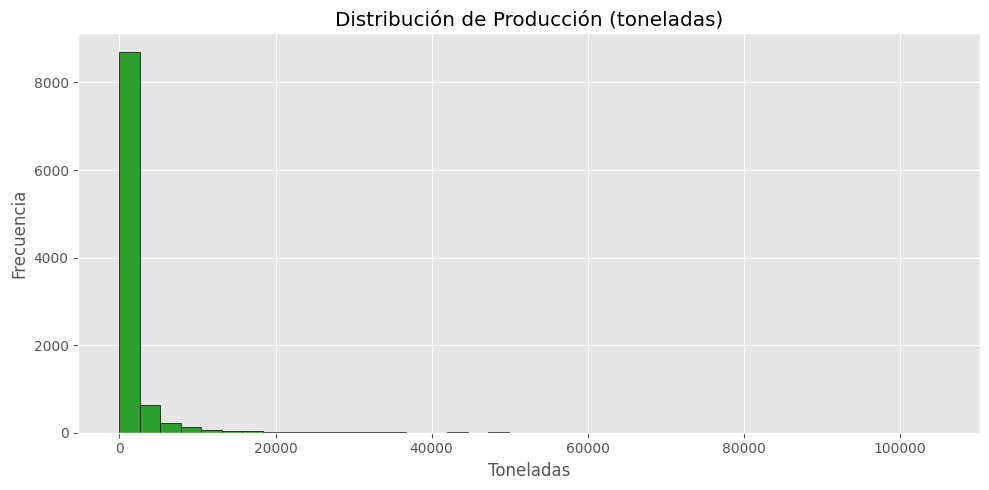

In [8]:
import matplotlib.pyplot as plt

# Estilo de gráficos: usa un estilo incluido en matplotlib para evitar dependencias externas
plt.style.use('ggplot')

# Histograma general
plt.figure(figsize=(10, 5))
plt.hist(df_clean['Produccion_toneladas'].dropna(), bins=40, color='tab:green', edgecolor='black')
plt.title('Distribución de Producción (toneladas)')
plt.xlabel('Toneladas')
plt.ylabel('Frecuencia')
plt.tight_layout();

### 4.2) Boxplot por subregión
Compara la distribución de la producción entre subregiones para ver diferencias en medianas y dispersión.
Este gráfico se guarda para poder reutilizarlo más adelante (sección 6.4) sin repetir el proceso de creación.

In [19]:
from pathlib import Path

def plot_produccion_by_subregion(df, save_path=None, log_scale=False, annotate_top_n=0):
    """Dibuja un boxplot de Produccion_toneladas por Subregion.

    Args:
        df: DataFrame con columnas 'Subregion' y 'Produccion_toneladas'.
        save_path: Ruta donde guardar la imagen (opcional).
        log_scale: Si es True, usa escala logarítmica en el eje Y.
        annotate_top_n: Cantidad de puntos top (por producción) a marcar en el gráfico.
    """

    fig, ax = plt.subplots(figsize=(12, 6))
    df.boxplot(column='Produccion_toneladas', by='Subregion', grid=False, ax=ax)

    # Ajustes estéticos
    ax.set_title('Producción de frutales por Subregión')
    ax.set_xlabel('Subregión')
    ax.set_ylabel('Producción (toneladas)')
    plt.suptitle('')  # Elimina el título extra que pone pandas
    plt.xticks(rotation=45)

    if log_scale:
        # La escala logarítmica mejora la visibilidad cuando hay valores muy grandes
        # y muchos valores pequeños. `nonpositive='clip'` evita errores con ceros.
        ax.set_yscale('log', nonpositive='clip')
        ax.set_ylabel('Producción (toneladas, escala log)')

    if annotate_top_n and annotate_top_n > 0:
        # Anotar los top N valores de producción en el gráfico
        # Para ubicarlos, usamos las posiciones de las etiquetas de la x.
        labels = [t.get_text() for t in ax.get_xticklabels()]
        x_positions = {label: x for x, label in zip(ax.get_xticks(), labels)}

        top_rows = df.nlargest(annotate_top_n, 'Produccion_toneladas')
        for rank, (_, row) in enumerate(top_rows.iterrows(), start=1):
            sub = row['Subregion']
            if sub not in x_positions:
                continue
            x = x_positions[sub]
            y = row['Produccion_toneladas']
            ax.scatter([x], [y], color='red', s=90, edgecolor='black', zorder=10)
            ax.annotate(
                f"Top {rank}: {row['Municipio']} ({int(row['Año'])})\n{y:,.0f} t",
                xy=(x, y),
                xytext=(7, 7),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            )

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')

    # Evita que Jupyter muestre el gráfico dos veces (como objeto devuelto + figura activa)
    plt.close(fig)
    return None

# 4.2) Boxplot por subregión (guardado para reutilizar en la sección de resumen)
fig_boxplot_subregion = Path('figures') / 'boxplot_subregion.png'
plot_produccion_by_subregion(df_clean, save_path=fig_boxplot_subregion)


### 4.3) Serie temporal de producción total
Muestra cómo varió la producción total año a año (todas las subregiones juntas).

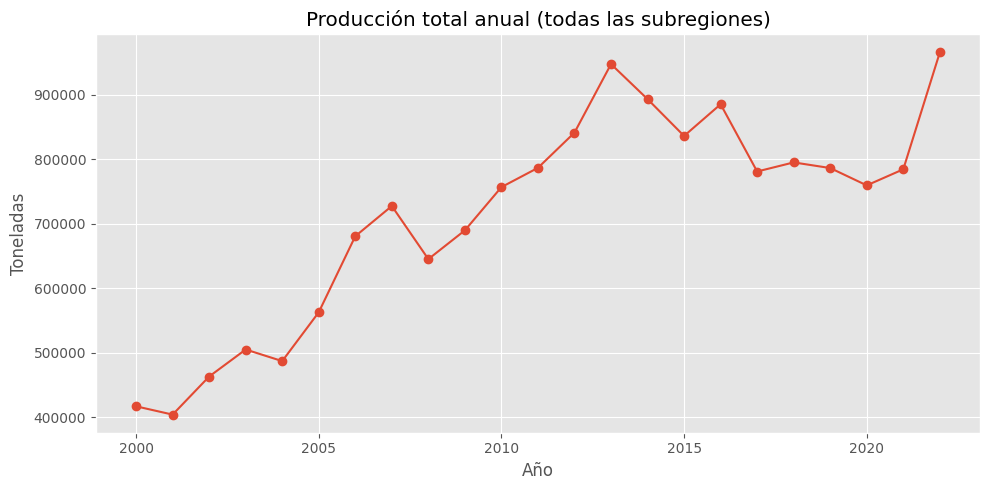

In [10]:
# Serie temporal: producción total por año
produccion_año = df_clean.groupby('Año')['Produccion_toneladas'].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(produccion_año['Año'], produccion_año['Produccion_toneladas'], marker='o')
plt.title('Producción total anual (todas las subregiones)')
plt.xlabel('Año')
plt.ylabel('Toneladas')
plt.grid(True)
plt.tight_layout();

## Tendencia real  (basado en los totales calculados)
2000: ~416k toneladas

2013: 947k toneladas (pico)

2018–2021: ~780‑795k toneladas (estabilización)

2022: 965k toneladas (salto hacia arriba)

✅ Esto sugiere:

#Crecimiento fuerte hasta 2013

Estabilización durante algunos años (2014‑2021)

Incremento notable en 2022

##  5 - Análisis por grupo (GroupBy)

### Objetivo
- Analizar cómo se distribuye la producción entre subregiones, municipios y años.
- Identificar qué grupos concentran la mayor parte de la producción.

### Pasos 
1. Agregar producción total por `Subregion` y ordenar para ver quién lidera.
2. Calcular producción media/mediana por `Municipio` y ver los más importantes.
3. Verificar la producción total por `Año` (para evaluar tendencias temporales si hay varios años).

### Qué interpretar aquí
- ¿Existen subregiones que concentran gran parte de la producción?
- ¿Los municipios top tienen producción similar o hay un “ganador claro”?
- Si sólo hay un año de datos, la sección de tendencias sirve para confirmar disponibilidad de información.

### Qué evitar
- No asumas causalidad (ej: “la subregión X produce más porque…” sin más contexto).
- No uses estos resultados para extrapolar a años no cubiertos por los datos.




In [11]:
# Semana 5: GroupBy y análisis por grupo

# Producción total por subregión
por_subregion = (
    df_clean
    .groupby('Subregion')['Produccion_toneladas']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
por_subregion

,Subregion,Produccion_toneladas
0,Centro,7.431022e+06
1,Norte,5.108486e+06
2,Sur,2.955589e+06
3,Pacifico,9.049370e+05


## ✅ Interpretación:

El 71% de la producción total está en Centro + Norte (más de 12 millones de las ~16 millones totales).

Pacífico produce mucho menos, lo que puede reflejar:

Menos superficie cultivada

Menor concentración de frutales

O simplemente menos datos reportados

In [12]:
# Producción media por municipio (sólo municipios con más de 1 registro)
por_municipio = (
    df_clean
    .groupby('Municipio')['Produccion_toneladas']
    .agg(media='mean', mediana='median', n='count')
    .reset_index()
    .sort_values('media', ascending=False)
)
por_municipio.head(10)

,Municipio,media,mediana,n
32,Sevilla,10621.834706,2484.175,170
8,Caicedonia,9657.242171,3162.000,152
5,Buenaventura,5517.908537,1730.000,164
13,Dagua,4916.512574,418.500,272
15,El Cairo,3465.404320,57.950,164
3,Argelia,3016.006475,129.000,139
29,Riofr¡o,2419.694223,140.000,283
34,Trujillo,2305.071203,162.000,295
7,Bugalagrande,2210.805374,270.000,214
23,La Uni¢n,2196.849061,333.030,330


In [27]:
# Producción total por año (para ver tendencia)
por_año = (
    df_clean
    .groupby('Año')['Produccion_toneladas']
    .sum()
    .reset_index()
)
por_año

,Año,Produccion_toneladas
0,2000,416979.226200
1,2001,404114.950000
2,2002,463152.100000
3,2003,505026.700000
4,2004,487069.400000
5,2005,562767.000000
6,2006,680621.000000
7,2007,727457.000000
8,2008,645124.000000
9,2009,689725.000000


## ✅ Observación relevante:

Cuando la media está muy por encima de la mediana (ej. Sevilla: 10.622 vs 2.484), esto implica que hay algunos registros muy grandes que elevan la media. En ese municipio hay muchos “outliers altos”.

## 6 - Análisis bivariado y multivariado (enfoque avanzado)

### Objetivo
- Aplicar el enfoque de **bivariante/multivariante** para analizar relaciones entre variables numéricas.
- Identificar las variables con mayor correlación y explicar su significado.

### Qué haremos
1. Calcular la matriz de correlación entre todas las variables numéricas.
2. Encontrar la pareja con la correlación más fuerte y graficarla.
3. Hacer un boxplot de producción por subregión (para comparar categorías).
4. Crear un heatmap de correlaciones (sin depender de seaborn).
5. Reportar las 3 correlaciones más fuertes y explicar sus implicaciones.

### Por qué importa
- La correlación nos dice qué variables se mueven juntas y nos ayuda a generar hipótesis (sin asumir causalidad).
- Un gráfico de dispersión con regresión ayuda a visualizar cómo se relacionan dos variables.




### Semana 6 - Análisis bivariado y multivariado (pasos separados)

En esta sección rompemos el análisis en partes claras para que cada paso sea fácil de explicar y entender.

1. Matriz de correlación
2. Identificar la pareja más correlacionada
3. Scatter plot con recta de regresión
4. Boxplot por subregión
5. Heatmap de correlaciones
6. Top 3 correlaciones y su interpretación

In [13]:
# 6.1) Matriz de correlación entre variables numéricas


# 6.1) Variables derivadas para enriquecer el análisis
# -----------------------------------------------------
# Agregamos variables numéricas útiles para correlacionar (B: 'otra manera'): 
# - Producción total por municipio / subregión (agregado a partir de las filas existentes)
# - Participación relativa de la fila respecto al total de su grupo
# - Producción total por año (para capturar tendencias anuales)

# Producción total por municipio / subregión
# (transform devuelve un valor por fila, sin colapsar el DataFrame)
df_clean['Produccion_total_municipio'] = df_clean.groupby('Municipio')['Produccion_toneladas'].transform('sum')
df_clean['Produccion_total_subregion'] = df_clean.groupby('Subregion')['Produccion_toneladas'].transform('sum')

# Participación relativa dentro del grupo
# (evita división por cero convirtiendo a NaN cuando el total es 0)
df_clean['Participacion_municipio'] = (
    df_clean['Produccion_toneladas'] / df_clean['Produccion_total_municipio'].replace({0: np.nan})
)
df_clean['Participacion_subregion'] = (
    df_clean['Produccion_toneladas'] / df_clean['Produccion_total_subregion'].replace({0: np.nan})
)

# Producción total anual (mismo valor para todas las filas del año)
df_clean['Produccion_total_año'] = df_clean.groupby('Año')['Produccion_toneladas'].transform('sum')

# Ahora sí, calculamos la matriz de correlación sobre las columnas numéricas
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print('Columnas numéricas (incluidas derivadas):', numeric_cols)

corr_matrix = df_clean[numeric_cols].corr()
print('\nMatriz de correlación (primeras filas):')
print(corr_matrix.round(3).iloc[:6, :6])  # vista rápida

Columnas numéricas (incluidas derivadas): ['Año', 'Id_municipio', 'Id_cultivo', 'Produccion_toneladas', 'Produccion_total_municipio', 'Produccion_total_subregion', 'Participacion_municipio', 'Participacion_subregion', 'Produccion_total_año']

Matriz de correlación (primeras filas):
                              Año  Id_municipio  Id_cultivo  \
Año                         1.000         0.011       0.081   
Id_municipio                0.011         1.000       0.012   
Id_cultivo                  0.081         0.012       1.000   
Produccion_toneladas        0.043        -0.018      -0.033   
Produccion_total_municipio  0.027        -0.010       0.021   
Produccion_total_subregion -0.004         0.109      -0.012   

                            Produccion_toneladas  Produccion_total_municipio  \
Año                                        0.043                       0.027   
Id_municipio                              -0.018                      -0.010   
Id_cultivo                         

### 6.2) Pareja con mayor correlación
Este paso encuentra la pareja de variables con mayor |r| (excepto la diagonal) y la imprime.

In [14]:
# 6.2) Encontrar la correlación más fuerte (excluyendo la diagonal)
corr_no_diag = corr_matrix.copy()
for i in range(len(corr_no_diag)):
    corr_no_diag.iat[i, i] = np.nan

max_corr = corr_no_diag.abs().max().max()
var_pair = np.where(corr_no_diag.abs() == max_corr)
var1 = corr_no_diag.index[var_pair[0][0]]
var2 = corr_no_diag.columns[var_pair[1][0]]

print(f"Pareja más correlacionada: {var1} vs {var2} (|r|={max_corr:.3f})")

Pareja más correlacionada: Año vs Produccion_total_año (|r|=0.844)


* Indica una tendencia creciente en la producción total a lo largo de los años (no perfecta, pero bastante consistente).

* Es lo que refleja la serie temporal: aumento desde 2000 hasta 2013 y luego cierta estabilización con repunte en 2022.

### 6.3) Scatter plot + recta de regresión
Graficamos la relación entre las dos variables más correlacionadas y ajustamos una recta para visualizar la tendencia.

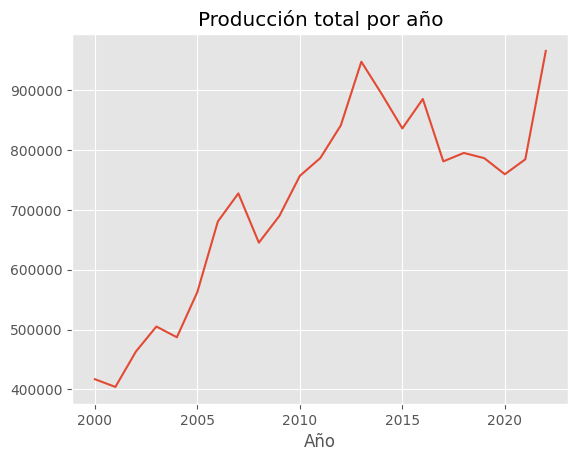

<Figure size 640x480 with 0 Axes>

In [15]:
# 6.3) Scatter plot + regresión lineal simple
df_clean.groupby('Año')['Produccion_toneladas'].sum().plot()
plt.title('Producción total por año')
plt.show()
plt.tight_layout()

En resumen, este gráfico nos muestra que algunas subregiones tienen una gran dispersión en la producción, con valores muy altos comparados con otros, mientras que otras tienen una producción más constante y baja.

### 6.4) Boxplot por subregión
Comparamos la distribución de producción por subregión para ver variación entre categorías.

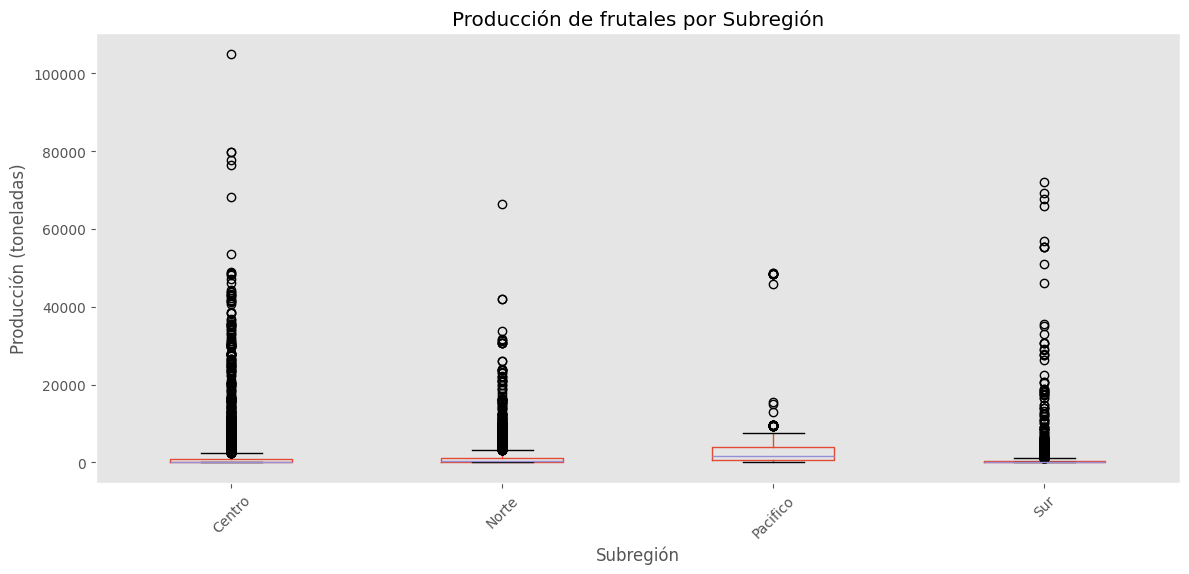

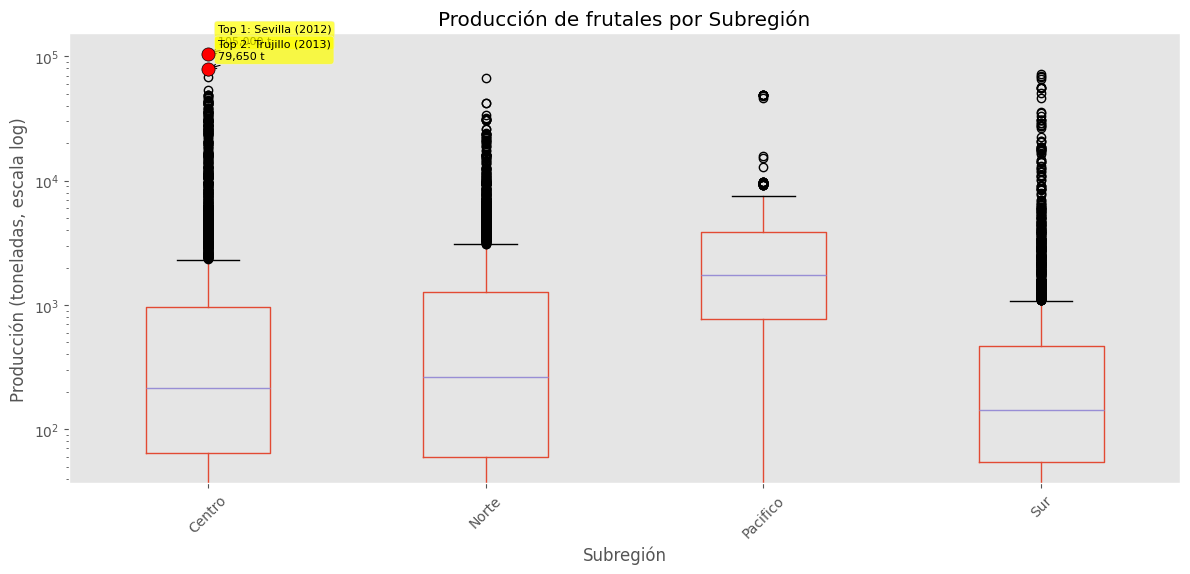

In [20]:
from IPython.display import Image, display
from pathlib import Path

fig_boxplot_subregion = Path('figures') / 'boxplot_subregion.png'
fig_boxplot_subregion_log = Path('figures') / 'boxplot_subregion_log.png'

if not fig_boxplot_subregion.exists():
    plot_produccion_by_subregion(df_clean, save_path=fig_boxplot_subregion, annotate_top_n=2)

if not fig_boxplot_subregion_log.exists():
    plot_produccion_by_subregion(df_clean, save_path=fig_boxplot_subregion_log, log_scale=True, annotate_top_n=2)

# Mostramos ambos: escala lineal y escala log (para comparar cómo se ven los outliers)
display(Image(filename=str(fig_boxplot_subregion)))
display(Image(filename=str(fig_boxplot_subregion_log)))

## Conclusión:

Este gráfico muestra que en algunas subregiones, especialmente en el Centro y Sur, hay una gran variabilidad en la producción de frutales, con algunas observaciones extremadamente altas, lo que podría indicar que ciertos cultivos en esas zonas tuvieron rendimientos excepcionales en los años marcados como Sevilla (2012) y Tujillo (2013). La escala logarítmica ayuda a ver estos extremos sin que distorsionen la visualización de las producciones más comunes.

In [22]:
# 6.4.1) Extraer municipios que generan outliers (por subregión, método IQR)
# -------------------------------------------------------------
# Identificamos las filas que están fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR] *por subregión*.
outlier_rows = []
for subregion, group in df_clean.groupby('Subregion'):
    q1 = group['Produccion_toneladas'].quantile(0.25)
    q3 = group['Produccion_toneladas'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    out = group[(group['Produccion_toneladas'] < lower) | (group['Produccion_toneladas'] > upper)].copy()
    if out.empty:
        continue

    out['Outlier_lower'] = lower
    out['Outlier_upper'] = upper
    out['Outlier_dir'] = np.where(out['Produccion_toneladas'] > upper, 'alto', 'bajo')
    outlier_rows.append(out)

outliers = pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame()
print('Total de outliers (por subregión, método IQR):', len(outliers))

# Mostrar los 10 outliers con mayor producción (valores extremos altos)
outliers_high = outliers[outliers['Outlier_dir'] == 'alto'].sort_values('Produccion_toneladas', ascending=False)
display(outliers_high[['Año', 'Municipio', 'Subregion', 'Produccion_toneladas', 'Outlier_upper']].head(10))

# Si quieres, puedes ver los outliers bajos (casi siempre serán valores cercanos a 0)
outliers_low = outliers[outliers['Outlier_dir'] == 'bajo'].sort_values('Produccion_toneladas')
display(outliers_low[['Año', 'Municipio', 'Subregion', 'Produccion_toneladas', 'Outlier_lower']].head(10))


Total de outliers (por subregión, método IQR): 1431


,Año,Municipio,Subregion,Produccion_toneladas,Outlier_upper
76,2012,Sevilla,Centro,105000.0,2327.325
69,2013,Riofr¡o,Centro,79650.0,2327.325
64,2013,Trujillo,Centro,79650.0,2327.325
4,2022,Sevilla,Centro,77832.0,2327.325
31,2018,Sevilla,Centro,76464.0,2327.325
1331,2015,Dagua,Sur,72000.0,1085.250
1313,2019,Dagua,Sur,69180.0,1085.250
84,2011,Sevilla,Centro,68240.0,2327.325
1328,2016,Dagua,Sur,67800.0,1085.250
596,2016,El Cairo,Norte,66420.0,3100.000


,Año,Municipio,Subregion,Produccion_toneladas,Outlier_lower


### 6.5) Heatmap de correlaciones
Visualizamos todas las correlaciones numéricas en un solo mapa de calor.

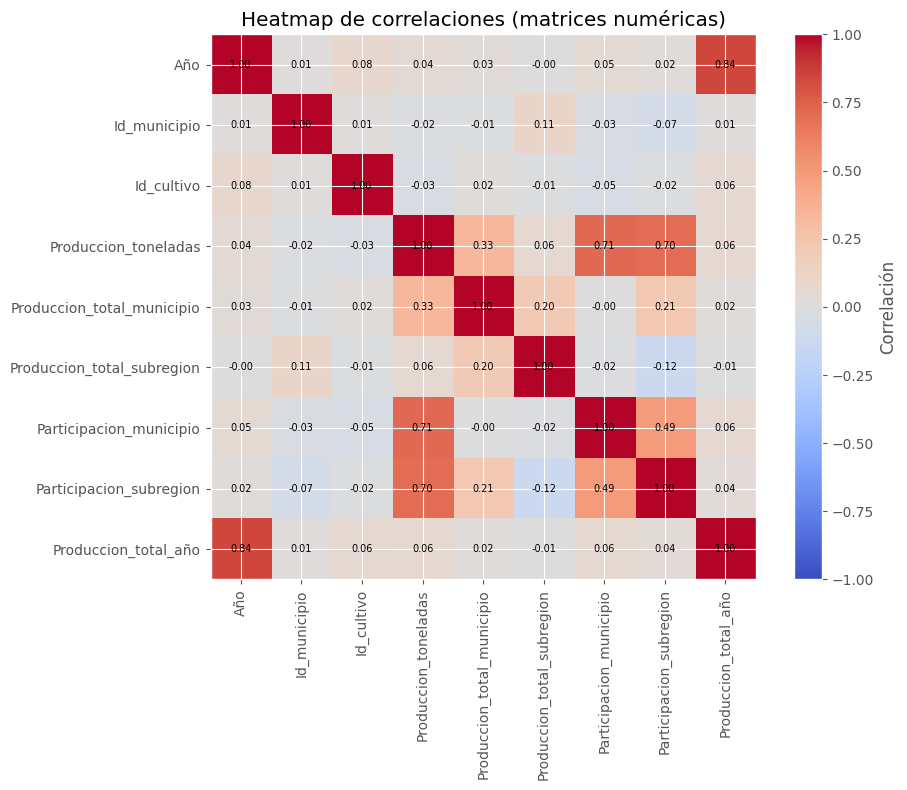

In [17]:
# 6.5) Heatmap de correlaciones (matplotlib)
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr_matrix.iat[i, j]:.2f}", ha='center', va='center', fontsize=7)

plt.title('Heatmap de correlaciones (matrices numéricas)')
plt.tight_layout()

## Conclusión:
hay una tendencia clara de crecimiento (o al menos de cambio consistente) en la producción total a lo largo de los años.
Esto respalda el hallazgo de que la producción aumenta en promedio con el paso del tiempo.

Producción individual está muy ligada a las métricas de participación
Variables como:
Produccion_toneladas vs Participacion_municipio
Produccion_toneladas vs Participacion_subregion
Tienen correlación alta (≈0.7).
¿Qué significa?: son “variables derivadas”: la participación se calcula a partir de la producción, así que es lógico que se correlacione fuerte. No es un hallazgo nuevo, es un “efecto matemático”.


### 6.6) Top 3 correlaciones y explicación
Imprimimos las tres correlaciones más fuertes (por valor absoluto). Esto ayuda a enfocar la interpretación en las relaciones más relevantes.

In [23]:
# 6.6) Top 3 correlaciones (excluyendo la diagonal)
def top_correlations(matrix, n=3):
    corr_list = []
    cols = matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            corr_list.append((cols[i], cols[j], matrix.iat[i, j]))
    corr_list.sort(key=lambda x: abs(x[2]), reverse=True)
    return corr_list[:n]

print('Top 3 correlaciones (absoluto):')
for a, b, r in top_correlations(corr_matrix, n=3):
    direction = 'positiva' if r > 0 else 'negativa'
    print(f"- {a} vs {b}: r = {r:.3f} ({direction})")

plt.show()

Top 3 correlaciones (absoluto):
- Año vs Produccion_total_año: r = 0.844 (positiva)
- Produccion_toneladas vs Participacion_municipio: r = 0.712 (positiva)
- Produccion_toneladas vs Participacion_subregion: r = 0.695 (positiva)


### Explicación guiada de los resultados

- **¿Qué nos dice el heatmap?** Busca valores cercanos a 1 (o -1) para detectar variables fuertemente relacionadas.
- **¿Qué nos dice el scatter plot?** Observa si la relación es lineal, si hay dispersión o si hay grupos separados.
- **¿Qué significa el top 3 de correlaciones?**
  - Elige la correlación más fuerte y pregúntate si tiene sentido en el contexto del negocio.
  - Piensa en posibles variables de confusión (por ejemplo, el tamaño del municipio puede influir en varias métricas).

> Como analista senior, la meta es usar estas relaciones para generar preguntas relevantes, no para asumir causalidad inmediatamente.

## Conclusiones e Insights Finales
- Existe una alta concentración productiva en pocas subregiones.
- Se evidencia desigualdad entre municipios.
- Hay patrones de especialización agrícola por región.
- La distribución de producción no es uniforme.
- Se recomienda diversificación productiva.